from IPython.display import Image
Image('imagens/flatten.png')

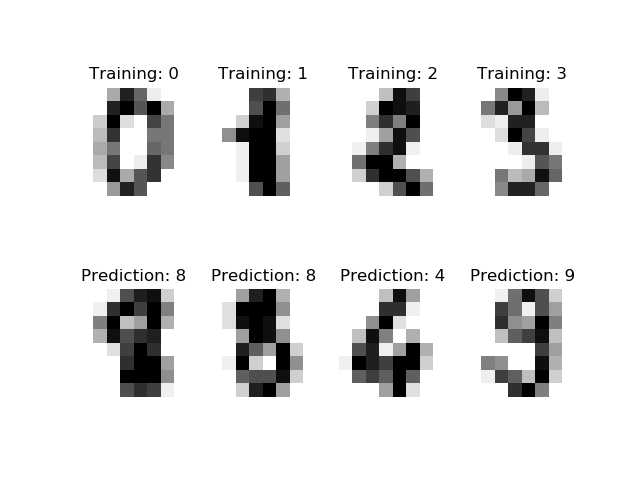

In [7]:
# Visualizando imagem 
from IPython.display import Image
Image('imagens/digitos.png')

In [173]:
# Carrega os pacotes
import numpy as np
from sklearn import datasets
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [100]:
# Conjunto de dados: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html

In [27]:
conjunto_dados = datasets.load_digits()

In [37]:
# Visualizando Dados
conjunto_dados

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

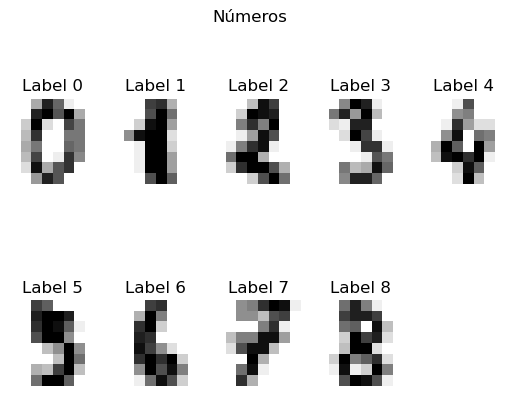

In [71]:
# Visualizando imagens do conjunto de dados
# Link de referência: https://matplotlib.org/stable/gallery/index.html & https://scikit-learn.org/stable/auto_examples/classification/plot_digits_classification.html
imagens_labels = list(zip(conjunto_dados.images, conjunto_dados.target))
for index, (image, label) in enumerate(imagens_labels[:9]):
    plt.subplot(2, 5, index + 1)
    plt.axis('off')
    plt.imshow(image, cmap = plt.cm.gray_r, interpolation='nearest')
    plt.title('Label %i' % label)
    plt.suptitle('Números')

In [85]:
# Definindo váriaveis
X = conjunto_dados.data
Y = conjunto_dados.target

In [87]:
# Verificando shape dos dados
print(x.shape, y.shape)

(1797, 64) (1797,)


#### Pré_Processamento e Normalização

In [104]:
# Divisão treino e teste
# Link de referência: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html#sklearn.model_selection.train_test_split
X_treino, testeData, Y_treino, testeLabels = train_test_split(X, Y, test_size = 0.30, random_state = 40)

In [110]:
# Divisão dos dados de treino em dados de treino e dados de validação
treinoData, validData, treinoLabels, validLabels = train_test_split(X_treino, 
                                                                    Y_treino, 
                                                                    test_size = 0.1, 
                                                                    random_state = 70)

In [112]:
# Imprindo a quantidade de dados de cada dataset
print('Exemplos de Treino; {}'.format(len(treinoLabels)))
print('Exemplos de Validação; {}'.format(len(validLabels)))
print('Exemplos de Teste; {}'.format(len(testeLabels)))

Exemplos de Treino; 1131
Exemplos de Validação; 126
Exemplos de Teste; 540


In [116]:
# KNN - Prepocição de dados normalizados.
# Fazendo a normalização do conjunto de dados

# Cálculando média do conjunto de dados
X_norm = np.mean(X, axis = 0)


# Normalizando
X_treino_norm = treinoData - X_norm
X_valid_norm = validData - X_norm
X_test_norm = testeData  - X_norm

In [120]:
# Estrutura (shape) do conjunto de dados
print(X_treino_norm.shape, X_valid_norm.shape, X_test_norm.shape)

(1131, 64) (126, 64) (540, 64)


In [136]:
# Intervalo de valores K para teste
Kvalores = range(1, 30, 2)

In [138]:
# Armazenamento de acurácias 
acuracias = []

In [142]:
# Loop em todos os valores de K, testando eles
for k in Kvalores:

    # Treinando o modelo com cada valor
    modeloKNN = KNeighborsClassifier(n_neighbors = k)
    modeloKNN.fit(treinoData, treinoLabels)

    # Avaliando Modelo e atualizando acuracias 
    score = modeloKNN.score(validData, validLabels)
    print('Com o valor de k = %d a acurácia é = %.2f%%' % (k, score * 100))
    acuracias.append(score)

Com o valorde k = 1 a acurácia é = 98.41%
Com o valorde k = 3 a acurácia é = 99.21%
Com o valorde k = 5 a acurácia é = 100.00%
Com o valorde k = 7 a acurácia é = 99.21%
Com o valorde k = 9 a acurácia é = 98.41%
Com o valorde k = 11 a acurácia é = 98.41%
Com o valorde k = 13 a acurácia é = 99.21%
Com o valorde k = 15 a acurácia é = 99.21%
Com o valorde k = 17 a acurácia é = 99.21%
Com o valorde k = 19 a acurácia é = 99.21%
Com o valorde k = 21 a acurácia é = 99.21%
Com o valorde k = 23 a acurácia é = 98.41%
Com o valorde k = 25 a acurácia é = 97.62%
Com o valorde k = 27 a acurácia é = 97.62%
Com o valorde k = 29 a acurácia é = 97.62%


In [148]:
# Obtendo melhor valor de K com base na acurácia

melhor_valor = np.argmax(acuracias)
print('O valor de k = %d e alcançou a mais alta acurácia de %.2f%% nos dados de validação' % (Kvalores[melhor_valor],
                                                                                             acuracias[melhor_valor] * 100))

O valor de k = 5 e alcançou a mais alta acurácia de 100.00% nos dados de validação


#### Construção e Treinamento do Modelo KNN

In [155]:
# Contruindo versão final do modelo
ultimo_modelo = KNeighborsClassifier(n_neighbors = Kvalores[melhor_valor])

In [157]:
ultimo_modelo.fit(treinoData, treinoLabels)

KNeighborsClassifier()

In [161]:
predicao = ultimo_modelo.predict(testeData)

In [167]:
# Performance modelo nos dados teste
print('Avaliando modelos no conjunto de dados Teste')
print(classification_report(testeLabels, predicao))

Avaliando modelos no conjunto de dados Teste
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        44
           1       0.94      1.00      0.97        68
           2       1.00      1.00      1.00        52
           3       0.96      0.98      0.97        55
           4       1.00      0.98      0.99        53
           5       0.98      1.00      0.99        47
           6       1.00      1.00      1.00        58
           7       0.94      1.00      0.97        50
           8       0.96      0.88      0.92        58
           9       1.00      0.95      0.97        55

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540



In [181]:
# Confusion Matrix
img = confusion_matrix(testeLabels, predicao)
print('Confusion Matrix')
print(img)

Confusion Matrix
[[44  0  0  0  0  0  0  0  0  0]
 [ 0 68  0  0  0  0  0  0  0  0]
 [ 0  0 52  0  0  0  0  0  0  0]
 [ 0  0  0 54  0  0  0  1  0  0]
 [ 0  0  0  0 52  0  0  1  0  0]
 [ 0  0  0  0  0 47  0  0  0  0]
 [ 0  0  0  0  0  0 58  0  0  0]
 [ 0  0  0  0  0  0  0 50  0  0]
 [ 0  4  0  2  0  0  0  1 51  0]
 [ 0  0  0  0  0  1  0  0  2 52]]


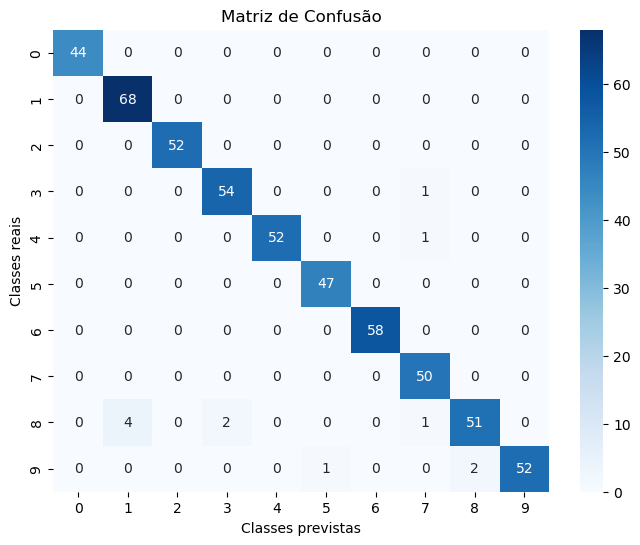

In [183]:
# Plotar heatmap
plt.figure(figsize=(8,6))
sns.heatmap(img, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Classes previstas')
plt.ylabel('Classes reais')
plt.title('Matriz de Confusão')
plt.show()

Eu acredito que esse seja: 5


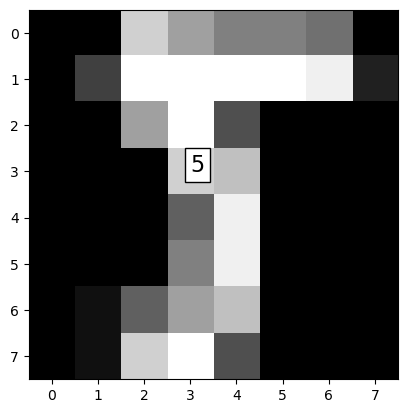

Eu acredito que esse seja: 5


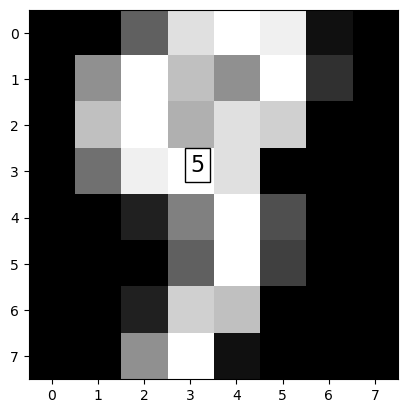

Eu acredito que esse seja: 6


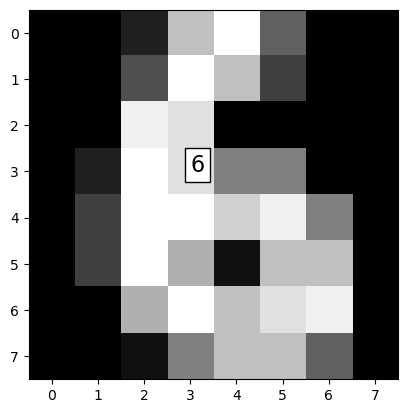

Eu acredito que esse seja: 2


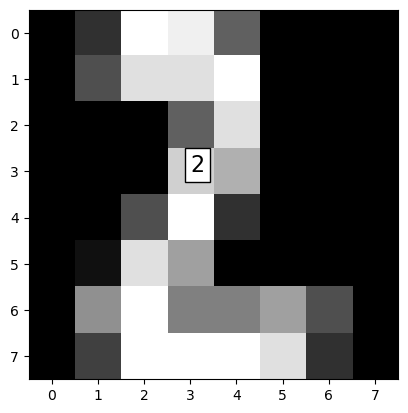

Eu acredito que esse seja: 6


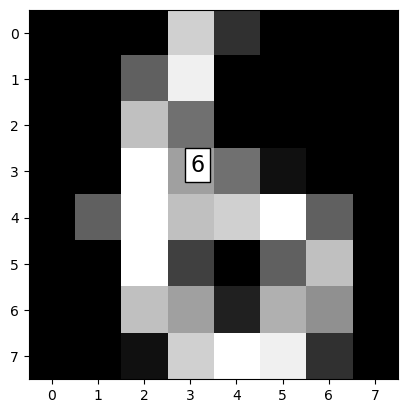

In [207]:
for i in np.random.randint(0, high=len(testeLabels), size=(5,)):

    # Obtem imagem e faz a previsao
    image = testeData[i]
    prediction = ultimo_modelo.predict([image]) [0]

    # Visualizar previsões
    imgdata = np.array(image, dtype='float')
    pixels = imgdata.reshape((8,8))
    plt.imshow(pixels, cmap = 'gray')
    plt.annotate(prediction, (3,3), bbox={'facecolor':'white'}, fontsize=16)
    print('Eu acredito que esse seja: {}'.format(prediction))
    plt.show()

In [257]:
# Novos dados de Entrada
novosDigitos = [2., 15., 16., 15., 14., 13.,  2.,  1.,
                1., 14.,  2.,  1.,  1.,  1.,  2.,  1.,
                2., 15.,  1.,  1.,  1.,  1.,  1.,  2.,
                1., 14., 15., 16., 14.,  2.,  1.,  1.,
                2.,  1.,  1.,  2.,  2., 15.,  2.,  2.,
                1.,  1.,  1.,  1.,  1., 14.,  1.,  1.,
                1., 15.,  2.,  2., 14., 16.,  2.,  1.,
                2., 14., 15., 15., 14.,  2.,  1.,  2.]

In [259]:
# Normalizando novos digitos
norm_novosDigitos = novosDigitos - X_norm

In [261]:
previsaoNova = ultimo_modelo.predict([norm_novosDigitos])

Eu acredito que esse seja: [5]


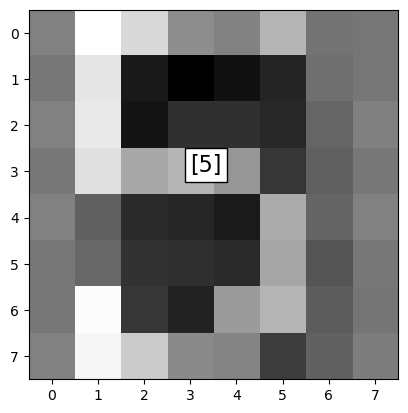

In [263]:
# Visualizar previsões
imgdata = np.array(norm_novosDigitos, dtype='float')
pixels = imgdata.reshape((8,8))
plt.imshow(pixels, cmap = 'gray')
plt.annotate(previsaoNova, (3,3), bbox={'facecolor':'white'}, fontsize=16)
print('Eu acredito que esse seja: {}'.format(previsaoNova))
plt.show()